## A note on what this is

This blender is an **experiment** — a demonstration of how much can still be squeezed out of an
already-solved task with nothing but statistics and arithmetic. There is no new model here, no new
feature, no new data: just a handful of existing submissions combined by weighted voting. The fact
that careful counting alone can nudge the leaderboard is itself the interesting result.

It is also, honestly, **not the cleanest way to solve the problem.** Blending finished submissions
optimizes the leaderboard, not understanding: it leans on scores other people (or earlier runs)
already produced, the gains live in a tiny sliver of disagreement rows, and without ground truth on
the test set every candidate has to be validated blindly by submitting. Treat it as a final polish
on top of real modeling — a way to study ensembling mechanics and harvest the last few thousandths —
not as a substitute for building a better model.

# Blender — Predicting Stellar Class

A two-layer submission blender. Metric is **balanced accuracy**; classes are `['GALAXY', 'QSO', 'STAR']`.

**Layer A — probability core (optional).** When out-of-fold and test probabilities of your own
models are available (`oof_*.npy` + `test_*.npy`), a meta stacker (logistic regression) is trained
with an honest OOF balanced-accuracy estimate. This is the only locally-measurable signal.

**Layer B — hard vote over external submissions.** External submissions carry only class labels
(not probabilities). They enter the blend as weighted votes, where each weight equals the
submission's leaderboard score.

**Merge.** On rows where the external submissions agree unanimously (~98.5%), their label is kept.
On the disagreement rows (~1.5%), a weighted vote decides: the probability core (if present) plus
the external votes.

## Inputs and outputs

This notebook is written to run on Kaggle and locally without edits.

- **`stellar_data` dataset** — mirrors `docs/external/`: a `submissions/` folder with one CSV per
  submission (filename = its leaderboard score, e.g. `0.97007.csv`), plus `star_classification.csv`.
  Optionally also `oof_*.npy` / `test_*.npy` for the probability core.
- **Competition dataset** — the folder that contains `train.csv` and `test.csv`. Its `train.csv`
  supplies the ground-truth labels used to validate the probability core.

Paths are auto-detected by scanning `/kaggle/input/*`. When not on Kaggle, the repository layout
under `competitions/predicting-stellar-class/` is used instead.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.metrics import balanced_accuracy_score

CLASSES = ['GALAXY', 'QSO', 'STAR']
C2I = {c: i for i, c in enumerate(CLASSES)}
np.random.seed(42)

PURPLE_BLUE = ['#3B2F8F', '#6A5ACD', '#9D7BE0', '#4169E1', '#7B68EE', '#5B8DEF']
CLASS_PALETTE = {'GALAXY': '#3B2F8F', 'QSO': '#6A5ACD', 'STAR': '#9D7BE0'}
SEQ_CMAP = 'BuPu'
sns.set_theme(style='whitegrid', palette=PURPLE_BLUE)
plt.rcParams['figure.dpi'] = 110

KAGGLE_INPUT = Path('/kaggle/input')
ON_KAGGLE = KAGGLE_INPUT.exists()


def find_dir(predicate, roots):
    for root in roots:
        if not root.exists():
            continue
        for p in [root, *sorted(root.rglob('*'))]:
            if p.is_dir() and predicate(p):
                return p
    return None


if ON_KAGGLE:
    search_roots = sorted(KAGGLE_INPUT.iterdir())
    SUBS_DIR = find_dir(lambda p: p.name == 'submissions' and any(p.glob('*.csv')), search_roots)
    assert SUBS_DIR is not None, 'no submissions/ folder found under /kaggle/input'
    STELLAR_DIR = SUBS_DIR.parent
    COMP_DIR = find_dir(lambda p: (p / 'train.csv').exists(), search_roots)
    OUT_DIR = Path('/kaggle/working')
else:
    REPO = Path('competitions/predicting-stellar-class') if Path('competitions').exists() else Path('..')
    STELLAR_DIR = REPO / 'docs' / 'external'
    SUBS_DIR = STELLAR_DIR / 'submissions'
    COMP_DIR = REPO / 'data_processed'
    OUT_DIR = REPO / 'data_processed'

print('on kaggle :', ON_KAGGLE)
print('stellar   :', STELLAR_DIR)
print('subs      :', SUBS_DIR)
print('comp      :', COMP_DIR)
print('out       :', OUT_DIR)

on kaggle : True
stellar   : /kaggle/input/datasets/flexonafft/stellar-data/external
subs      : /kaggle/input/datasets/flexonafft/stellar-data/external/submissions
comp      : /kaggle/input/competitions/playground-series-s6e6
out       : /kaggle/working


## 1. External submissions and their leaderboard-score weights

Every CSV in the `submissions/` folder is one external submission. The filename is parsed as its
leaderboard score and used directly as its voting weight. All submissions are aligned on `id`.

In [2]:
sub_files = sorted(SUBS_DIR.glob('*.csv'))
assert sub_files, f'no submissions found in {SUBS_DIR}'

scores = {f.stem: float(f.stem) for f in sub_files}
subs = {f.stem: pd.read_csv(f).sort_values('id').reset_index(drop=True) for f in sub_files}

ref_id = subs[sub_files[0].stem]['id'].values
for name, df in subs.items():
    assert np.array_equal(df['id'].values, ref_id), f'{name}: id mismatch'

names = list(subs)
print(f'{len(names)} submissions, {len(ref_id)} rows')

L = np.column_stack([subs[n]['class'].map(C2I).values for n in names])
S = np.array([scores[n] for n in names])

# --- Weight stretching ------------------------------------------------------
# Raw LB scores barely differ (~0.969..0.970), so weighting by the raw score is
# almost a uniform vote. We rescale the scores so the gap between submissions
# actually drives the vote on disagreement rows.
#   'raw'     : w = score                       (original behaviour)
#   'shifted' : w = score - min(score) + eps    (weight ~ "how much better than worst")
#   'softmax' : w = softmax((score-max)/T)      (sharper; smaller T -> winner-takes-more)
WEIGHT_MODE = 'softmax'
SOFTMAX_T = 0.0005

def make_weights(s, mode=WEIGHT_MODE, T=SOFTMAX_T):
    s = np.asarray(s, dtype=float)
    if mode == 'raw':
        return s.copy()
    if mode == 'shifted':
        return s - s.min() + 1e-3
    if mode == 'softmax':
        e = np.exp((s - s.max()) / T)
        return e / e.sum()
    raise ValueError(mode)

# --- Diversity-aware weighting (decorrelation) ------------------------------
# A hard vote double-counts near-duplicate submissions: two files that agree on
# 99.9% of rows effectively cast the same ballot twice. We scale each weight by
# an "uniqueness" factor = 1 / (mean agreement with the others), so a submission
# that merely echoes the panel loses pull while a differently-wrong one keeps it.
# This is applied on top of the score weight wherever the final blend is built.
USE_DECORR = True

def uniqueness(label_mat):
    k = label_mat.shape[1]
    agr = np.array([[(label_mat[:, a] == label_mat[:, b]).mean() for b in range(k)]
                    for a in range(k)])
    off = agr.copy(); np.fill_diagonal(off, np.nan)
    mean_agr = np.nanmean(off, axis=1)          # avg agreement with the rest
    u = 1.0 / mean_agr
    return u / u.mean()                          # normalise around 1.0

UNIQ = uniqueness(L) if USE_DECORR else np.ones(len(names))

W = make_weights(S)
print(f'\nweight mode: {WEIGHT_MODE}' + (f' (T={SOFTMAX_T})' if WEIGHT_MODE == 'softmax' else '')
      + f' | decorrelation: {USE_DECORR}')
Wd = W * UNIQ
Wd = Wd / Wd.sum()
for n, raw, w, u, wd in zip(names, S, W, UNIQ, Wd):
    print(f'  {n}: score={raw:.5f}  w={w:.5f}  uniq={u:.3f}  final={wd:.5f}',
          dict(subs[n]['class'].value_counts()))

9 submissions, 247435 rows

weight mode: softmax (T=0.0005) | decorrelation: True
  0.96874: score=0.96874  w=0.00531  uniq=1.003  final=0.00533 {'GALAXY': np.int64(156899), 'QSO': np.int64(51204), 'STAR': np.int64(39332)}
  0.96973: score=0.96973  w=0.03846  uniq=1.003  final=0.03860 {'GALAXY': np.int64(157408), 'QSO': np.int64(51515), 'STAR': np.int64(38512)}
  0.96996: score=0.96996  w=0.06093  uniq=0.999  final=0.06089 {'GALAXY': np.int64(157026), 'QSO': np.int64(51391), 'STAR': np.int64(39018)}
  0.97003: score=0.97003  w=0.07009  uniq=0.999  final=0.07003 {'GALAXY': np.int64(157186), 'QSO': np.int64(51379), 'STAR': np.int64(38870)}
  0.97007: score=0.97007  w=0.07592  uniq=0.999  final=0.07588 {'GALAXY': np.int64(157349), 'QSO': np.int64(51368), 'STAR': np.int64(38718)}
  0.97015: score=0.97015  w=0.08910  uniq=0.999  final=0.08900 {'GALAXY': np.int64(157202), 'QSO': np.int64(51376), 'STAR': np.int64(38857)}
  0.97047: score=0.97047  w=0.16897  uniq=1.000  final=0.16897 {'GALAXY'

## 2. Disagreement region

Rows where every submission already agrees carry no information for blending. The blend can only
ever change a label inside the disagreement region, so it is worth measuring how small that is.

In [3]:
unanimous = np.all(L == L[:, [0]], axis=1)
disagree = ~unanimous
print(f'unanimous rows: {unanimous.sum()} ({unanimous.mean()*100:.2f}%)')
print(f'disagree  rows: {disagree.sum()} ({disagree.mean()*100:.2f}%)')

unanimous rows: 243385 (98.36%)
disagree  rows: 4050 (1.64%)


### Submission agreement matrix

A blend can only help if its members make *different* mistakes. This heatmap shows the pairwise
agreement (share of identical predictions) between every pair of submissions. Bright near-100%
blocks reveal near-duplicate submissions: they vote together and dominate any plain majority vote,
so the effective diversity is lower than the submission count suggests.

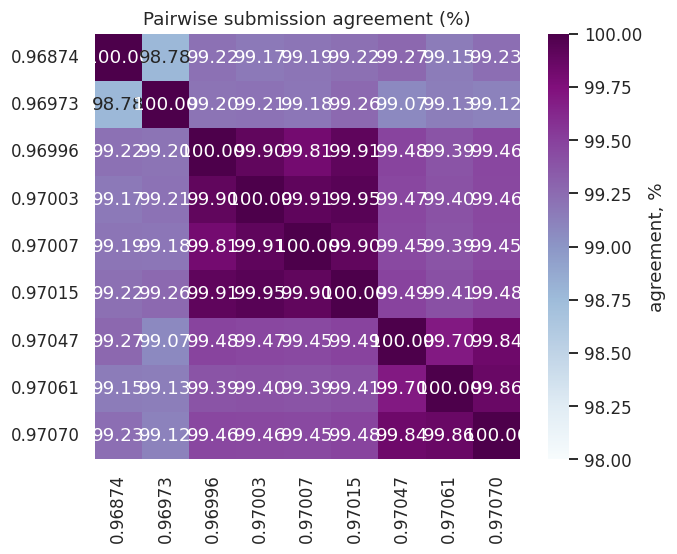

In [4]:
agree = np.zeros((len(names), len(names)))
for a in range(len(names)):
    for b in range(len(names)):
        agree[a, b] = (L[:, a] == L[:, b]).mean()

plt.figure(figsize=(6.5, 5.2))
sns.heatmap(pd.DataFrame(agree * 100, index=names, columns=names),
            annot=True, fmt='.2f', cmap=SEQ_CMAP, square=True,
            vmin=98, vmax=100, cbar_kws={'label': 'agreement, %'})
plt.title('Pairwise submission agreement (%)')
plt.tight_layout(); plt.show()

## 2b. Leave-one-submission-out validation (no ground truth)

There is no test-set ground truth, so Layer B normally can only be judged by submitting. A cheap
local proxy: hold out one submission, blend the remaining ones, and measure how well the blend
reproduces the held-out labels. We report it as **balanced accuracy** against the held-out
submission (treating it as pseudo-truth), so the imbalance is reflected the same way the real metric
is. The absolute number is not the leaderboard score — but it lets us compare weight schemes and the
class prior *without spending submissions*: a setting that consistently agrees better with strong
held-out submissions is the safer bet.

In [5]:
# --- Class prior --------------------------------------------------------------
# The metric is BALANCED accuracy, so multiplying the accumulated votes by
# 1/frequency *looks* like the right thing (favour the rare STAR/QSO classes).
# But here the votes are HARD counts, not probabilities: a prior of STAR x4.6 /
# QSO x3.25 over-flips disagreement rows into the rare classes even when the
# strong submissions clearly voted GALAXY. With the three new 0.9704+ signals
# added, the prior flipped ~684 rows off the best single submission and dragged
# the blend DOWN (0.97015 -> 0.97001). The submissions are already tuned for
# balanced accuracy, so the prior double-counts. Keep it OFF.
#   USE_CLASS_PRIOR=False -> exact original hard-vote behaviour (the safe choice).
# NOTE: the LOSO proxy in 2b prefers prior=True, but it only measures agreement
# with a held-out submission (pseudo-truth), not real accuracy, so it is biased
# toward whatever predicts more rare classes. Do not tune the prior on it.
USE_CLASS_PRIOR = False
CLASS_FREQ = np.array([0.65, 0.20, 0.14])           # GALAXY, QSO, STAR (from EDA)
CLASS_PRIOR = (1.0 / CLASS_FREQ) if USE_CLASS_PRIOR else np.ones(3)
CLASS_PRIOR = CLASS_PRIOR / CLASS_PRIOR.min()        # normalise so the cheapest class == 1
print('class prior (GALAXY,QSO,STAR):', np.round(CLASS_PRIOR, 3))


def weighted_vote(label_mat, weights, prior=CLASS_PRIOR):
    """Hard weighted vote -> predicted class index per row."""
    m = label_mat.shape[0]
    v = np.zeros((m, 3))
    for j in range(label_mat.shape[1]):
        np.add.at(v, (np.arange(m), label_mat[:, j]), weights[j])
    return (v * prior).argmax(1)


# Leave-one-submission-out: blend the rest, score against the held-out sub.
print(f'\nLOSO balanced accuracy vs held-out submission (weight={WEIGHT_MODE}, prior={USE_CLASS_PRIOR})')
loso = {}
for h in range(len(names)):
    keep = [j for j in range(len(names)) if j != h]
    pred = weighted_vote(L[:, keep], make_weights(S[keep]))
    loso[names[h]] = balanced_accuracy_score(L[:, h], pred)
    print(f'  held-out {names[h]} (score {S[h]:.5f}): {loso[names[h]]:.5f}')
print(f'  mean: {np.mean(list(loso.values())):.5f}  '
      f'| weighted-by-score: {np.average(list(loso.values()), weights=S):.5f}')

class prior (GALAXY,QSO,STAR): [1. 1. 1.]

LOSO balanced accuracy vs held-out submission (weight=softmax, prior=False)
  held-out 0.96874 (score 0.96874): 0.98894
  held-out 0.96973 (score 0.96973): 0.98918
  held-out 0.96996 (score 0.96996): 0.99245
  held-out 0.97003 (score 0.97003): 0.99298
  held-out 0.97007 (score 0.97007): 0.99330
  held-out 0.97015 (score 0.97015): 0.99328
  held-out 0.97047 (score 0.97047): 0.99686
  held-out 0.97061 (score 0.97061): 0.99787
  held-out 0.97070 (score 0.97070): 0.99836
  mean: 0.99369  | weighted-by-score: 0.99369


## 3. Layer A — probability core

The core is the only locally-measurable signal in this notebook, so we always build one.

- **Preferred — precomputed artifacts.** If `oof_*.npy` (row-aligned to the competition `train.csv`,
  class order = `CLASSES`) and matching `test_*.npy` are present, each pair is one base model; they
  are concatenated and fed to a logistic-regression meta-model. The OOF balanced accuracy is computed
  honestly via `cross_val_predict`.
- **Fallback — a cheap CPU core.** When no artifacts are found, we train a single
  `HistGradientBoostingClassifier` straight from `train.csv` (light feature engineering: SDSS colour
  indices + native categoricals). It is CPU-only, needs no GPU and no extra libraries, and runs in a
  couple of minutes. 5-fold OOF gives an honest balanced-accuracy estimate; a full-data refit scores
  the test set. The result is a genuine `core_test_proba` aligned to the submission rows.

Either way the core yields (a) an honest `core_oof_ba` (the core's credibility on train) and (b)
`core_test_proba`, a probabilistic opinion on every test row. Layer B uses (b) as a soft judge on the
disagreement rows and §4 uses it to rank the scenarios.

In [6]:
npy_roots = [STELLAR_DIR, COMP_DIR, OUT_DIR]
oof_paths, test_paths = [], []
for root in npy_roots:
    if root and root.exists():
        oof_paths += sorted(root.rglob('oof_*.npy'))
        test_paths += sorted(root.rglob('test_*.npy'))

have_probs = bool(oof_paths) and bool(test_paths)

core_test_proba = None
core_oof_ba = None
meta = meta_oof = y = None

from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import cross_val_predict, StratifiedKFold

# Resolve the folder that holds train.csv / test.csv (it is NOT data_processed here).
DATA_DIR = None
for cand in [COMP_DIR, STELLAR_DIR.parent / 'dataset', Path('..') / 'docs' / 'dataset',
             Path('competitions/predicting-stellar-class/docs/dataset')]:
    if cand and (cand / 'train.csv').exists() and (cand / 'test.csv').exists():
        DATA_DIR = cand
        break

if have_probs:
    # ---- Preferred path: stack precomputed OOF/test probabilities ----------
    from sklearn.linear_model import LogisticRegression
    print('probability artifacts: FOUND -> meta-stacker core')
    for p in oof_paths + test_paths:
        print('  ', p)

    train_csv = (DATA_DIR / 'train.csv') if DATA_DIR else (COMP_DIR / 'train.csv')
    if train_csv.exists():
        y = pd.read_csv(train_csv, usecols=['class'])['class'].map(C2I).values
    else:
        y = pd.read_parquet(COMP_DIR / 'train_fe.parquet')['target'].values

    suffix = lambda p: p.stem.split('_', 1)[1]
    oof_map = {suffix(p): np.load(p) for p in oof_paths}
    test_map = {suffix(p): np.load(p) for p in test_paths}
    keys = [k for k in oof_map if k in test_map]
    assert keys, 'no oof_*/test_* pairs with a shared suffix'
    print('models in stack:', keys)
    for k in keys:
        assert oof_map[k].shape[0] == len(y), f'{k}: oof rows {oof_map[k].shape} != {len(y)}'
        assert test_map[k].shape[0] == len(ref_id), f'{k}: test rows != {len(ref_id)}'

    Xoof = np.hstack([oof_map[k] for k in keys])
    Xtest = np.hstack([test_map[k] for k in keys])
    meta = LogisticRegression(max_iter=2000, C=1.0)
    skf = StratifiedKFold(5, shuffle=True, random_state=42)
    meta_oof = cross_val_predict(meta, Xoof, y, cv=skf, method='predict_proba')
    core_oof_ba = balanced_accuracy_score(y, meta_oof.argmax(1))
    meta.fit(Xoof, y)
    core_test_proba = meta.predict_proba(Xtest)
    assert list(meta.classes_) == list(range(3)), f'unexpected class order: {meta.classes_}'

elif DATA_DIR is not None:
    # ---- Fallback path: a cheap CPU core trained from train.csv ------------
    from sklearn.ensemble import HistGradientBoostingClassifier
    print(f'probability artifacts: none -> cheap CPU core (HistGradientBoosting) from {DATA_DIR}')

    NUM = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
    CAT = ['spectral_type', 'galaxy_population']

    def featurize(df):
        x = df[NUM].copy()
        # SDSS colour indices — the strongest engineered signals per EDA.
        x['u_g'] = df['u'] - df['g']
        x['g_r'] = df['g'] - df['r']
        x['r_i'] = df['r'] - df['i']
        x['i_z'] = df['i'] - df['z']
        x['u_z'] = df['u'] - df['z']
        for c in CAT:
            x[c] = df[c].astype('category')
        return x

    tr = pd.read_csv(DATA_DIR / 'train.csv')
    te = pd.read_csv(DATA_DIR / 'test.csv')
    y = tr['class'].map(C2I).values
    Xtr, Xte = featurize(tr), featurize(te)

    core = HistGradientBoostingClassifier(
        loss='log_loss', learning_rate=0.08, max_iter=400, max_leaf_nodes=63,
        l2_regularization=1.0, categorical_features='from_dtype',
        class_weight='balanced', random_state=42, early_stopping=True)

    skf = StratifiedKFold(5, shuffle=True, random_state=42)
    meta_oof = cross_val_predict(core, Xtr, y, cv=skf, method='predict_proba', n_jobs=1)
    core_oof_ba = balanced_accuracy_score(y, meta_oof.argmax(1))

    core.fit(Xtr, y)
    assert list(core.classes_) == list(range(3)), f'unexpected class order: {core.classes_}'
    proba = core.predict_proba(Xte)
    # Align test probabilities to the submission id order (ref_id).
    pos = pd.Series(np.arange(len(te)), index=te['id'].values)
    core_test_proba = proba[pos.loc[ref_id].values]
    meta = core
else:
    print('probability artifacts: none and train/test csv not found -> hard-vote mode')

if core_oof_ba is not None:
    print(f'\nprobability core OOF balanced accuracy = {core_oof_ba:.5f}')

probability artifacts: none -> cheap CPU core (HistGradientBoosting) from /kaggle/input/competitions/playground-series-s6e6

probability core OOF balanced accuracy = 0.96358


## 4. Scenario engine — a panel of defensible blends

A single blend is a single bet, and this close to the leaderboard ceiling one bet is fragile. So
instead of shipping one file we generate a small *panel* of scenarios that differ along two
interpretable axes, then submit the ones the daily budget allows.

- **trust** — the softmax temperature `T` controls how sharply weight concentrates on the very best
  submissions (small `T`, fewer flips) versus how much the whole panel gets a say (large `T`, more
  flips off the best single).
- **STAR** — an optional *mild* multiplier on the rare STAR class (the project's known weak recall),
  applied as a gentle nudge — not the heavy `1/freq` prior that demonstrably over-flipped rows into
  the rare classes and dragged an earlier blend down (`0.97015 → 0.97001`).

Every scenario is a decorrelated weighted hard vote plus the probability core. None invents an
out-of-envelope class distribution; each is a different, honest reading of the same panel.

**Ranking.** We no longer hard-code a "recommended" file — without test ground truth that was a
guess. Instead each scenario is scored by `core_exp_bacc`: its *expected* balanced accuracy under the
probability core's belief (`core_test_proba` treated as `P(true | row)`). That is a model opinion,
not the leaderboard — but it is a real, test-relevant number that ranks the panel honestly. Treat it
as a tie-breaker, then still spend submissions to confirm.

In [7]:
# === Scenario definitions =====================================================
# Each scenario is one (temperature, STAR-multiplier) reading of the same panel.
from dataclasses import dataclass

@dataclass
class Scenario:
    key: str          # short name -> submission_<key>.csv
    T: float          # softmax temperature (small = trust the best; large = trust the panel)
    star: float       # mild multiplier on the STAR class (1.0 = off)
    blurb: str        # one-line rationale

SCENARIOS = [
    Scenario('anchor',       1e-6,   1.00, 'Best single submission, untouched — the ceiling reference.'),
    Scenario('conservative', 4e-4,   1.00, 'Override the best only where the strong panel is near-unanimous.'),
    Scenario('consensus',    5e-4,   1.00, 'Balanced top-3-driven vote. Scored 0.97066 on the board.'),
    Scenario('democratic',   1.5e-3, 1.00, 'Let the whole panel speak — many more flips, higher-variance bet.'),
    Scenario('star_lean',    5e-4,   1.15, 'Consensus nudged toward STAR to chase its weak recall.'),
]

# The probability core (§3) is WEAKER than the external submissions (OOF ~0.964
# vs LB ~0.971), so it must not overturn a unanimous strong consensus. It only
# acts as a tempered tie-breaker INSIDE the disagreement region. CORE_WEIGHT
# scales its pull relative to the full external vote mass (1.0 = equal say).
CORE_WEIGHT = 0.5

best_name = max(names, key=lambda x: scores[x])
best_idx = L[:, names.index(best_name)]
n = len(ref_id)


def build_blend(T, star):
    """Decorrelated softmax(T) external hard vote; the core breaks ties only on the
    disagreement rows, and unanimous rows are always kept untouched."""
    w = make_weights(S, 'softmax', T) * UNIQ        # diversity-aware weights
    v = np.zeros((n, 3))
    for j in range(len(names)):
        np.add.at(v, (np.arange(n), L[:, j]), w[j])
    if core_test_proba is not None:
        v[disagree] += CORE_WEIGHT * float(w.sum()) * core_test_proba[disagree]
    pred = (v * np.array([1.0, 1.0, star])).argmax(1)
    pred[unanimous] = L[unanimous, 0]               # never break a unanimous vote
    return pred


def core_exp_bacc(pred):
    """Expected balanced accuracy of `pred` under the probability core's belief.
    Treats core_test_proba[r,c] as P(true=c | row r); not ground truth — a model
    opinion. Returns NaN when no core is available."""
    if core_test_proba is None:
        return np.nan
    P = core_test_proba
    recalls = []
    for c in range(3):
        hit = P[pred == c, c].sum()
        tot = P[:, c].sum()
        recalls.append(hit / tot if tot > 0 else 0.0)
    return float(np.mean(recalls))


preds, rows = {}, []
for sc in SCENARIOS:
    p = build_blend(sc.T, sc.star)
    preds[sc.key] = p
    flips = int((p != best_idx).sum())
    d = np.bincount(p, minlength=3)
    rows.append({'scenario': sc.key, 'T': sc.T, 'STARx': sc.star,
                 'flips_vs_best': flips,
                 'in_disagree': bool(np.all(disagree[p != best_idx])) if flips else True,
                 'core_exp_bacc': core_exp_bacc(p),
                 'GALAXY': int(d[0]), 'QSO': int(d[1]), 'STAR': int(d[2]),
                 'rationale': sc.blurb})

summary = pd.DataFrame(rows).set_index('scenario')
print(f'best single submission : {best_name}')
print('all flips stay inside the disagreement region:', bool(summary['in_disagree'].all()))
if summary['core_exp_bacc'].notna().any():
    top = summary['core_exp_bacc'].idxmax()
    print(f'highest expected-bacc under the core : {top} '
          f'({summary.loc[top, "core_exp_bacc"]:.5f}) — a model-belief ranking, not ground truth')
summary[['T', 'STARx', 'flips_vs_best', 'core_exp_bacc', 'GALAXY', 'QSO', 'STAR', 'rationale']]

best single submission : 0.97070
all flips stay inside the disagreement region: True
highest expected-bacc under the core : democratic (0.94385) — a model-belief ranking, not ground truth


,T,STARx,flips_vs_best,core_exp_bacc,GALAXY,QSO,STAR,rationale
scenario,,,,,,,,
anchor,0.000001,1.00,0,0.943263,157214,51378,38843,"Best single submission, untouched — the ceilin..."
conservative,0.000400,1.00,95,0.943508,157218,51372,38845,Override the best only where the strong panel ...
consensus,0.000500,1.00,165,0.943556,157224,51359,38852,Balanced top-3-driven vote. Scored 0.97066 on ...
democratic,0.001500,1.00,510,0.943848,157213,51350,38872,"Let the whole panel speak — many more flips, h..."
star_lean,0.000500,1.15,180,0.943779,157163,51355,38917,Consensus nudged toward STAR to chase its weak...


### Comparing the scenarios

Three views of the panel. **Left:** how far each scenario steps off the best single submission —
the `flips_vs_best` count is, quite literally, the size of the bet each scenario is making.
**Right:** how those flips reshape the class counts *relative to the anchor*, so you can see at a
glance whether a scenario is feeding GALAXY, QSO or STAR. A healthy scenario nudges; it never lurches
to an extreme. **Below:** the pairwise agreement between scenarios — they all live within a few
hundred rows of each other (everything happens inside the 1.5% disagreement region), so the panel is
a set of *close, correlated* bets, not wild alternatives.

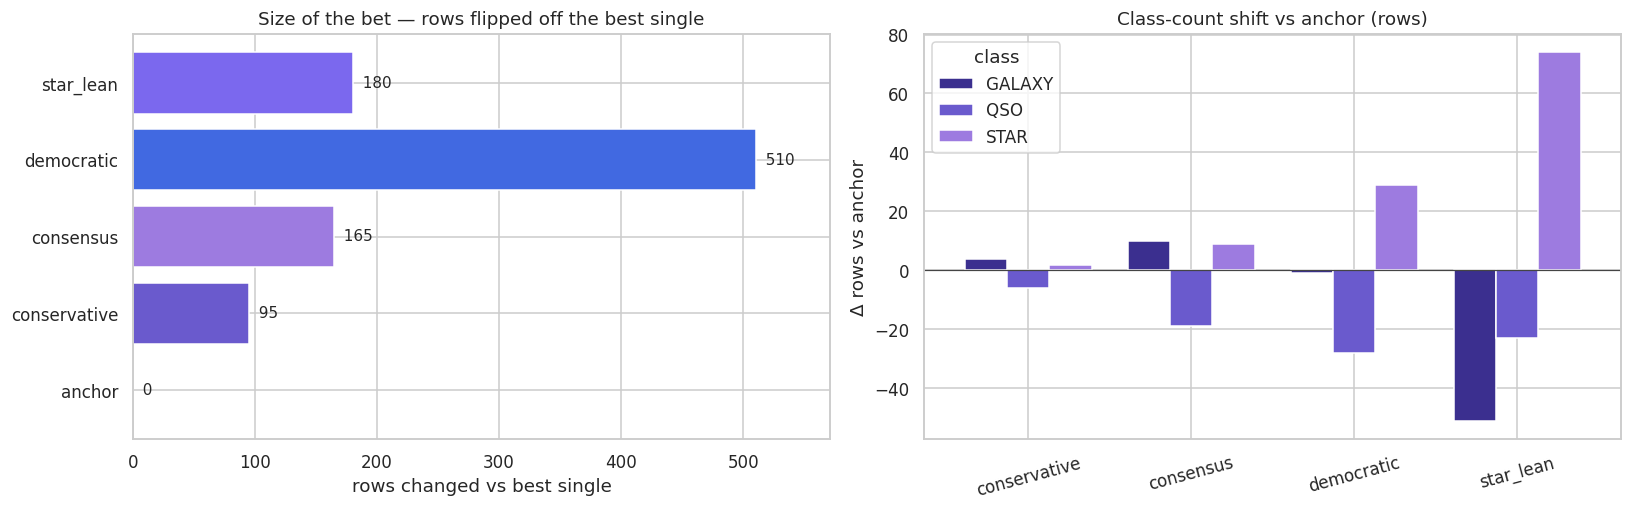

In [8]:
order = summary.index.tolist()
bar_colors = [PURPLE_BLUE[i % len(PURPLE_BLUE)] for i in range(len(order))]

fig, ax = plt.subplots(1, 2, figsize=(15, 4.8))

# (a) size of the bet — rows flipped off the best single submission
ax[0].barh(order, summary['flips_vs_best'], color=bar_colors)
for y, v in enumerate(summary['flips_vs_best']):
    ax[0].text(v, y, f'  {v}', va='center', fontsize=10)
ax[0].set_title('Size of the bet — rows flipped off the best single')
ax[0].set_xlabel('rows changed vs best single')
ax[0].margins(x=0.12)

# (b) class-count shift versus the anchor scenario
anchor_d = summary.loc['anchor', CLASSES].astype(int)
delta = summary[CLASSES].astype(int).subtract(anchor_d, axis=1).drop('anchor')
delta.plot(kind='bar', ax=ax[1], width=0.78,
           color=[CLASS_PALETTE[c] for c in CLASSES])
ax[1].axhline(0, color='#444', lw=0.8)
ax[1].set_title('Class-count shift vs anchor (rows)')
ax[1].set_ylabel('Δ rows vs anchor'); ax[1].set_xlabel('')
ax[1].tick_params(axis='x', rotation=15); ax[1].legend(title='class')

plt.tight_layout(); plt.show()

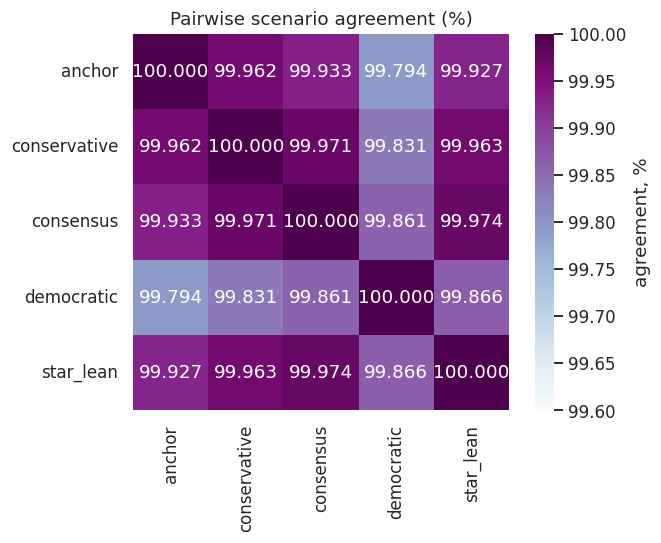

In [9]:
keys = list(preds)
A = np.array([[(preds[a] == preds[b]).mean() for b in keys] for a in keys])

plt.figure(figsize=(6.4, 5.1))
sns.heatmap(pd.DataFrame(A * 100, index=keys, columns=keys),
            annot=True, fmt='.3f', cmap=SEQ_CMAP, square=True,
            vmin=99.6, vmax=100, cbar_kws={'label': 'agreement, %'})
plt.title('Pairwise scenario agreement (%)')
plt.tight_layout(); plt.show()

## 5. Write the grouped submissions

Every scenario is written to its own file, `submission_<scenario>.csv` (`id,class`), and a
`manifest.csv` records what each one is — its temperature, STAR multiplier, flip count, expected
balanced accuracy under the core, and class distribution — so a later self can tell the files apart
without re-deriving them. The plain `submission.csv` defaults to `anchor` (the best single
submission) as an honest safe choice; there is no hard-coded "recommended" file. With a
10-submissions-per-day budget the natural order is the one §6 prints, ranked by the core's expected
balanced accuracy: confirm the ceiling with **anchor**, then spend the rest top-down.

In [10]:
written = []
for sc in SCENARIOS:
    lbl = np.array(CLASSES)[preds[sc.key]]
    assert pd.Series(lbl).isin(CLASSES).all()
    path = OUT_DIR / f'submission_{sc.key}.csv'
    pd.DataFrame({'id': ref_id, 'class': lbl}).to_csv(path, index=False)
    written.append(path.name)

# The plain submission.csv defaults to the honest safe choice: the best single
# submission (anchor). No scenario is hard-coded as "recommended" — without test
# ground truth that label was a guess; pick a file from the panel deliberately.
DEFAULT = 'anchor'
def_lbl = np.array(CLASSES)[preds[DEFAULT]]
pd.DataFrame({'id': ref_id, 'class': def_lbl}).to_csv(OUT_DIR / 'submission.csv', index=False)

manifest = summary.reset_index()
manifest.insert(1, 'file', [f'submission_{k}.csv' for k in manifest['scenario']])
manifest.to_csv(OUT_DIR / 'manifest.csv', index=False)

print(f'wrote {len(written)} scenario files + submission.csv (={DEFAULT}) + manifest.csv to:')
print(' ', OUT_DIR.resolve())
print(' ', ', '.join(written))
manifest[['scenario', 'file', 'flips_vs_best', 'core_exp_bacc', 'GALAXY', 'QSO', 'STAR']]

wrote 5 scenario files + submission.csv (=anchor) + manifest.csv to:
  /kaggle/working
  submission_anchor.csv, submission_conservative.csv, submission_consensus.csv, submission_democratic.csv, submission_star_lean.csv


,scenario,file,flips_vs_best,core_exp_bacc,GALAXY,QSO,STAR
0,anchor,submission_anchor.csv,0,0.943263,157214,51378,38843
1,conservative,submission_conservative.csv,95,0.943508,157218,51372,38845
2,consensus,submission_consensus.csv,165,0.943556,157224,51359,38852
3,democratic,submission_democratic.csv,510,0.943848,157213,51350,38872
4,star_lean,submission_star_lean.csv,180,0.943779,157163,51355,38917


## 6. A note from the field — what blending buys you at the ceiling

This task is, for all practical purposes, solved: the panel of submissions agrees on **98.4%** of
the test set, and the strongest single file already sits at **0.97070** balanced accuracy. Everything
a blender can ever do lives in the remaining **~1.6%** — about 4,000 rows where the submissions
disagree. That tiny sliver is the entire playing field, and it sets hard limits on what is and isn't
worth doing.

**Three things this experiment makes concrete.**

1. **Diversity, not count, is the currency.** The pairwise agreement matrix in §2 shows several
   submissions are near-duplicates; adding another copy of an opinion you already hold does nothing.
   The decorrelation weighting in §1 makes this explicit — it scales each vote by how *differently*
   it predicts, so an echo of the panel loses pull and a differently-wrong file keeps it.

2. **A metric-shaped prior is not a metric-shaped fix.** Balanced accuracy rewards rare-class recall,
   so re-weighting votes by `1/frequency` looks correct on paper. But on *hard* vote counts it
   over-flips confident GALAXY rows into STAR/QSO and cost us real score (`0.97015 → 0.97001`). The
   submissions are already tuned for the metric; the prior double-counts. A gentle, surgical STAR
   nudge (`star_lean`) is the honest version of the same intuition.

3. **You can buy a little local signal — cheaply, and with caveats.** There is still no test ground
   truth, so the leaderboard remains the only true judge. But a CPU probability core (§3) trained on
   `train.csv` gives two honest things: an OOF balanced accuracy (its own credibility) and a
   probabilistic opinion on every test row. The latter lets §4 rank the panel by *expected* balanced
   accuracy instead of a hard-coded "recommended" guess. It is a model belief, not the truth — so the
   output is still a *panel*: `anchor` confirms the ceiling, and the rest are calibrated probes spent
   top-down by that ranking to learn the shape of the hidden test set rather than guessing it.

The honest summary: blending finished submissions is a **polish**, not a method. It can harvest the
last few thousandths and it sharpens one's intuition about ensembling mechanics — but the score that
matters was earned upstream, by the models that produced these files. Treat this notebook as the
final, careful pass over work that was already good.

In [11]:
# --- Submission plan ----------------------------------------------------------
# Order the panel by the core's expected balanced accuracy when available (a
# model-belief ranking, NOT ground truth), else fall back to the size of the bet.
WHY = {
    'anchor':       'confirm the ceiling (best single, no blend)',
    'consensus':    'balanced top-3-driven vote',
    'conservative': 'fewer, higher-confidence flips than consensus',
    'star_lean':    'probe the STAR weak spot',
    'democratic':   'high-variance: trust the whole panel',
}
if summary['core_exp_bacc'].notna().any():
    ordered = summary.sort_values('core_exp_bacc', ascending=False).index.tolist()
    print('suggested submission order (by core expected-bacc; model belief, not truth):\n')
else:
    ordered = summary.sort_values('flips_vs_best').index.tolist()
    print('suggested submission order (no core -> by size of the bet):\n')

for i, k in enumerate(ordered, 1):
    f = int(summary.loc[k, 'flips_vs_best'])
    eb = summary.loc[k, 'core_exp_bacc']
    eb_s = f'exp-bacc {eb:.5f} | ' if pd.notna(eb) else ''
    print(f'  {i}. submission_{k}.csv  ({eb_s}{f:>4d} flips vs best) — {WHY.get(k, "")}')
print(f'\nplain submission.csv == submission_{DEFAULT}.csv (honest safe default)')

suggested submission order (by core expected-bacc; model belief, not truth):

  1. submission_democratic.csv  (exp-bacc 0.94385 |  510 flips vs best) — high-variance: trust the whole panel
  2. submission_star_lean.csv  (exp-bacc 0.94378 |  180 flips vs best) — probe the STAR weak spot
  3. submission_consensus.csv  (exp-bacc 0.94356 |  165 flips vs best) — balanced top-3-driven vote
  4. submission_conservative.csv  (exp-bacc 0.94351 |   95 flips vs best) — fewer, higher-confidence flips than consensus
  5. submission_anchor.csv  (exp-bacc 0.94326 |    0 flips vs best) — confirm the ceiling (best single, no blend)

plain submission.csv == submission_anchor.csv (honest safe default)
